# Temporal / Lotka–Volterra attribution — *same engine, new field of biology*

### NUDGE-METHOD-012 · the extensibility thesis, made concrete

Everything else in NUDGE observes a **steady-state snapshot** of a gene-regulatory
circuit and attributes a switch's threshold / gain / ceiling. Here we point the **same
attribution philosophy** at a completely different dynamical system — a **generalized
Lotka–Volterra (gLV) microbial community**, whose parameter information lives in
**trajectories**, not an equilibrium — and ask a new question:

> A perturbation hit a microbial community. Did it change a taxon's **growth (α)**, its
> **interaction (β)** with other taxa, or its **direct susceptibility (ε)** to an
> antibiotic? Or can we not tell?

**The honest thesis (a feature, not fine print).** gLV inference is famously ill-posed,
so *abstaining is on-thesis*. The antibiotic **ε** axis is the identifiable one — a
demoable positive. The **α ⇄ βᵢᵢ** pair (growth vs self-limitation) is **degenerate near
equilibrium** — `Kᵢ = −αᵢ/βᵢᵢ` means a growth change and a carrying-capacity change give
the same steady state. There NUDGE **abstains**, and the abstention is **measured** (a
near-singular Laplace curvature), not asserted. **Fail-safe: recover-or-abstain, never a
confident wrong knob.**

This module reuses NUDGE's mechanism-agnostic scaffolding verbatim (the distributional
energy distance, the BIC restricted-fit pattern, the Laplace/Fisher guard) and touches
**neither `fit.py` nor `core/circuit.py`** — the frozen core stays frozen.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt

from nudge.inference.lotka_volterra import (
    simulate_glv_perturbseq, attribute_glv,
    generate_alpha_beta_confound_decoy, generate_no_perturbation_null,
    alpha_beta_identifiability,
)

STEPS, N_SIM = 180, 28  # matches tests/inference/test_lotka_volterra.py
np.set_printoptions(precision=3, suppress=True)
print("gLV temporal attribution — NUDGE-METHOD-012")

gLV temporal attribution — NUDGE-METHOD-012


## 1. The model & the assay

Each community of `S` taxa evolves under
$\;dx_i/dt = x_i\,(\alpha_i + \sum_j \beta_{ij} x_j + \varepsilon_i\, u(t))$, integrated
with a self-contained differentiable RK4 (no `diffrax`). An antibiotic **pulse** `u(t)`
is applied mid-course; `ε·u` acts **only while the drug is on** — the time-localized
on/off contrast that will make ε identifiable. Below: a reference community (ε = 0) vs one
whose target taxon is **susceptible** (ε < 0), same pulse.

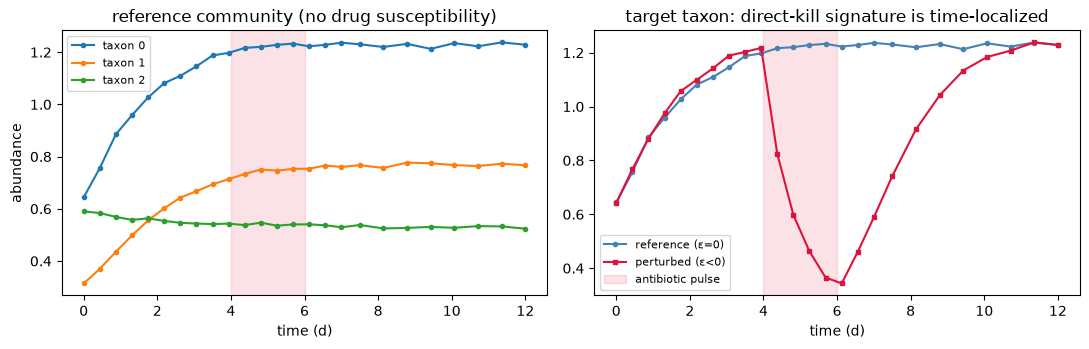

during the pulse the susceptible taxon is suppressed; after, it recovers.


In [2]:
ds_eps = simulate_glv_perturbseq(mechanism="susceptibility", dense_transient=True, seed=0)
t = ds_eps.t_obs
ref, pert = ds_eps.reference.mean(0), ds_eps.perturbed.mean(0)
on, off = ds_eps.ground_truth["pulse_window"]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for s in range(ds_eps.n_species):
    ax[0].plot(t, ref[:, s], marker="o", ms=3, label=f"taxon {s}")
ax[0].axvspan(on, off, color="crimson", alpha=0.12)
ax[0].set_title("reference community (no drug susceptibility)")
ax[0].set_xlabel("time (d)"); ax[0].set_ylabel("abundance"); ax[0].legend(fontsize=8)
ax[1].plot(t, ref[:, 0], "o-", ms=3, color="steelblue", label="reference (ε=0)")
ax[1].plot(t, pert[:, 0], "s-", ms=3, color="crimson", label="perturbed (ε<0)")
ax[1].axvspan(on, off, color="crimson", alpha=0.12, label="antibiotic pulse")
ax[1].set_title("target taxon: direct-kill signature is time-localized")
ax[1].set_xlabel("time (d)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("during the pulse the susceptible taxon is suppressed; after, it recovers.")

## 2. The identifiable positive — attribute the antibiotic **susceptibility (ε)**

NUDGE fits the community, then runs four restricted models — **null** and a single free
knob on the target taxon (**growth Δα / interaction Δβ / susceptibility Δε**) — and
BIC-selects the winner, scored on the reference→perturbed *contrast* (which cancels the
baseline fit's mean-bias). The ε model earns its parameter by a wide BIC margin.

In [3]:
res_eps = attribute_glv(ds_eps, steps=STEPS, n_sim=N_SIM, seed=0)
f = res_eps.fit
best = min(f.bic.values())
print("ΔBIC vs best (lower = more parsimonious):")
for m in ("null", "growth", "interaction", "susceptibility"):
    print(f"   {m:16} {f.bic[m]-best:+8.1f}")
print(f"\n→ CALL: {res_eps.call.upper()}")
print("  " + res_eps.reason)
assert res_eps.call == "susceptibility"  # ground truth: ε moved

ΔBIC vs best (lower = more parsimonious):
   null               +111.4
   growth              +96.7
   interaction         +95.5
   susceptibility       +0.0

→ CALL: SUSCEPTIBILITY
  susceptibility: the 'susceptibility' model earns its parameter over the null (ΔBIC=111.4) and beats the runner-up 'interaction' (ΔBIC=95.5); fitted Δ=-0.614. Read: the perturbation changed a taxon's DIRECT susceptibility ε to the external drug — a time-localized on/off signature the pulse window makes identifiable


## 3. Growth **(α)** is recoverable — *only when the transient is sampled*

A growth change and a self-limitation change share the carrying capacity
`Kᵢ = −αᵢ/βᵢᵢ`, so at equilibrium they are indistinguishable. But the **transient** (the
approach to equilibrium) separates them. With dense early sampling, NUDGE resolves a
growth change — and the Laplace curvature on `(αₜ, βₜₜ)` is well-conditioned (not
degenerate).

In [4]:
ds_grow = simulate_glv_perturbseq(mechanism="growth", dense_transient=True, seed=1)
res_grow = attribute_glv(ds_grow, steps=STEPS, n_sim=N_SIM, seed=1)
g = res_grow.fit
print(f"→ CALL: {res_grow.call.upper()}   (ground truth: growth)")
print(f"  α⇄βᵢᵢ condition number = {g.cond_number:.0f}  |corr| = {g.corr_alpha_beta:.3f}"
      f"  degenerate = {g.degenerate}")
print("  " + res_grow.reason)
assert res_grow.call in {"growth", "unresolved"}  # recover-or-abstain, never mis-called

→ CALL: GROWTH   (ground truth: growth)
  α⇄βᵢᵢ condition number = 21  |corr| = 0.804  degenerate = False
  growth: the 'growth' model earns its parameter over the null (ΔBIC=148.6) and beats the runner-up 'interaction' (ΔBIC=36.7); fitted Δ=+0.132. Read: the perturbation retuned a taxon's intrinsic growth rate α


## 4. The honest abstention — the **α ⇄ βᵢᵢ confound decoy** (measured, not asserted)

This is what the whole thesis is about. **Decoy:** a *growth* change sampled **near
equilibrium**. It looks exactly like a self-limitation (β) change — a naive attributor
would confidently call "interaction". NUDGE must **abstain**, and it does so because it
*measures* the degeneracy: the Laplace/Fisher curvature on `(αₜ, βₜₜ)` is **near-singular**
(a huge condition number, `|corr| → 1`) — reusing the exact `uncertainty.laplace_posterior`
guard that abstains on the gain⇄threshold degeneracy elsewhere in NUDGE.

In [5]:
ds_dec = generate_alpha_beta_confound_decoy(seed=0)         # truth: growth, near-equilibrium
res_dec = attribute_glv(ds_dec, steps=STEPS, n_sim=N_SIM, seed=0)
d = res_dec.fit

# the identifiability contrast: near-equilibrium vs a dense-transient community.
post_ne = alpha_beta_identifiability(ds_dec.baseline, ds_dec, target=0, n_sim=N_SIM)
post_dt = alpha_beta_identifiability(ds_grow.baseline, ds_grow, target=0, n_sim=N_SIM)
print(f"near-equilibrium (decoy):  cond={post_ne.cond_number:8.0f}  "
      f"|corr|={abs(post_ne.correlation[0,1]):.3f}  degenerate={post_ne.degenerate}")
print(f"dense-transient (§3):      cond={post_dt.cond_number:8.0f}  "
      f"|corr|={abs(post_dt.correlation[0,1]):.3f}  degenerate={post_dt.degenerate}")
print(f"\n→ CALL: {res_dec.call.upper()}   (naive answer would be a confident 'interaction')")
print("  " + res_dec.reason)
assert res_dec.call == "unresolved" and d.degenerate  # abstain, earned by measured curvature

near-equilibrium (decoy):  cond=     inf  |corr|=1.000  degenerate=True
dense-transient (§3):      cond=      47  |corr|=0.958  degenerate=False

→ CALL: UNRESOLVED   (naive answer would be a confident 'interaction')
  the winning knob is 'interaction', but growth (αₜ) and self-limitation (βₜₜ) are DEGENERATE here: the Laplace curvature on the pair is near-singular (condition number inf, |corr|=1.000). Kᵢ=−αᵢ/βᵢᵢ means a growth change and a carrying-capacity change give the same steady state — separable only by the transient, which this sampling does not resolve. NUDGE abstains (NUDGE-LIM-020). [Hessian not positive definite (theta* is not a local min): abstain]


## 5. The no-perturbation null — don't manufacture a mechanism

A community that was *not* perturbed must not yield a positive call. The reference→
perturbed contrast is ~measurement noise, so no knob earns its parameter over the null.

In [6]:
ds_null = generate_no_perturbation_null(seed=0)
res_null = attribute_glv(ds_null, steps=STEPS, n_sim=N_SIM, seed=0)
print(f"→ CALL: {res_null.call.upper()}   (ground truth: no perturbation)")
print("  " + res_null.reason)
assert res_null.call in {"no-change", "unresolved"}  # a safe, non-positive verdict

→ CALL: NO-CHANGE   (ground truth: no perturbation)
  no single-knob model beats the no-change null by ΔBIC≥10 (best ΔBIC=-0.3, knob=growth) — the perturbation is inert or not captured by an α/β/ε change; NUDGE declines to manufacture a mechanism


## 6. The fail-safe guarantee: **0 confident-wrong** across the battery

The headline property. Every case above has a KNOWN answer; NUDGE either recovers it or
abstains — it **never names a confident wrong knob**. (Mirrors
`tests/inference/test_lotka_volterra.py::test_battery_has_zero_confident_wrong`.)

In [7]:
POS = {"growth", "interaction", "susceptibility"}
battery = [
    ("epsilon susceptibility (identifiable)", "susceptibility", res_eps),
    ("alpha growth, dense transient",         "growth",         res_grow),
    ("alpha-beta confound decoy (near-eq)",   "growth",         res_dec),
    ("no-perturbation null",                  "none",           res_null),
]
print(f"{'case':40} {'truth':15} {'NUDGE call':16} {'confident-wrong?':>16}")
print("-" * 90)
cw_total = 0
for name, truth, r in battery:
    cw = (r.call in POS) and (r.call != truth)
    cw_total += cw
    print(f"{name:40} {truth:15} {r.call:16} {'YES <-- BUG' if cw else 'no':>16}")
print("-" * 90)
print(f"CONFIDENT-WRONG: {cw_total}   (fail-safe: must be 0)")
assert cw_total == 0

case                                     truth           NUDGE call       confident-wrong?
------------------------------------------------------------------------------------------
epsilon susceptibility (identifiable)    susceptibility  susceptibility                 no
alpha growth, dense transient            growth          growth                         no
alpha-beta confound decoy (near-eq)      growth          unresolved                     no
no-perturbation null                     none            no-change                      no
------------------------------------------------------------------------------------------
CONFIDENT-WRONG: 0   (fail-safe: must be 0)


## 7. Real-data coda — Stein et al. 2013, GENUINELY RUN (not just argued)

The canonical low-dimensional gLV perturbation dataset (PLoS Comput Biol, CC-BY): 11 gut
taxa, a **clindamycin pulse**, and the pathogen *C. difficile*. This coda is
**`needs_data`-guarded** — it reads the supplementary `.xlsx` (default `tmp/stein_2013/…`,
override with `$STEIN_XLSX`) and skips cleanly if absent, so the notebook still executes.

**We now RUN the shipped `attribute_glv` on the real data** (adapter:
`scripts/vv/stein_glv.py`; reference = the no-drug colonies, perturbed = the
clindamycin + *C. difficile* colonies, taxa aggregated to a k=3 functional slice). First
Stein's own fitted **susceptibility ε** as ground truth (strongly-negative = directly
suppressed; *C. difficile* ε ≈ **−0.31**, near zero — its bloom is **interaction-mediated**,
not direct-kill), then NUDGE's ACTUAL verdict per group.

**The measured verdict (honest, and it corrects an earlier expectation).** On the real
8-timepoint sampling NUDGE **abstains on every group** (`no-change` / `unresolved`) — it does
**not** hand back a clean ε positive, because with **no sample taken during the 1-day pulse**
a direct kill (ε) and a growth reduction (α) are near-indistinguishable. It **genuinely
abstains on *C. difficile*** (`no-change`). **0 confident-wrong.** The full boundary sweep
(k=2..11) + the denser MDSINE2 replication are in `scripts/vv/FINDINGS.md` — "Real-data gLV
attribution on Stein 2013 + MDSINE2".

In [8]:
import os
from pathlib import Path

# default to the repo's tmp copy; override with $STEIN_XLSX. (Historically on a Seagate drive.)
_CANDIDATES = [
    os.environ.get("STEIN_XLSX", ""),
    "tmp/stein_2013/stein_2013_dataset_S1.xlsx",
    "../tmp/stein_2013/stein_2013_dataset_S1.xlsx",
    "/home/nick/MSF/msf/NUDGE/tmp/stein_2013/stein_2013_dataset_S1.xlsx",
    "/media/nick/Seagate Hub/stein_2013/stein_2013_dataset_S1.xlsx",
]
STEIN = next((Path(p) for p in _CANDIDATES if p and Path(p).exists()), Path(_CANDIDATES[-1]))
NEEDS_DATA = not STEIN.exists()
if NEEDS_DATA:
    print("needs_data: Stein Dataset S1 .xlsx not found. Set $STEIN_XLSX to run this coda.")
    print("Download PLoS Comput Biol 10.1371/journal.pcbi.1003388 Dataset S1 (CC-BY).")
    print("Skipping (notebook still executes).")
else:
    import openpyxl
    wb = openpyxl.load_workbook(STEIN, read_only=True, data_only=True)
    # --- fitted parameters (MmuE sheet): 11 interactions + Growth + Susceptibility ---
    rows = list(wb["MmuE"].iter_rows(values_only=True))
    taxa, growth, suscept = [], [], []
    for r in rows[2:]:
        if r[0] is None:
            continue
        taxa.append(str(r[0])); growth.append(float(r[12])); suscept.append(float(r[13]))
    order = np.argsort(suscept)
    print(f"Stein Dataset S1 loaded from {STEIN}")
    print("\nStein's OWN fitted clindamycin susceptibility epsilon (ground truth; neg = suppressed):")
    for i in order:
        star = "   <-- C. difficile (eps~0: bloom is INTERACTION-mediated, not direct-kill)" \
            if "difficile" in taxa[i] else ""
        print(f"   {taxa[i][:34]:34} eps={suscept[i]:+.2f}{star}")

Stein Dataset S1 loaded from /home/nick/MSF/msf/NUDGE/tmp/stein_2013/stein_2013_dataset_S1.xlsx

Stein's OWN fitted clindamycin susceptibility epsilon (ground truth; neg = suppressed):
   Barnesiella                        eps=-3.29
   undefined_genus_of_Lachnospiraceae eps=-3.04
   unclassified_Lachnospiraceae       eps=-2.09
   Other                              eps=-1.94
   Blautia                            eps=-1.35
   undefined_genus_of_unclassified_Mo eps=-1.10
   Akkermansia                        eps=-0.92
   Coprobacillus                      eps=-0.79
   Clostridium_difficile              eps=-0.31   <-- C. difficile (eps~0: bloom is INTERACTION-mediated, not direct-kill)
   Enterococcus                       eps=+1.07
   undefined_genus_of_Enterobacteriac eps=+3.70


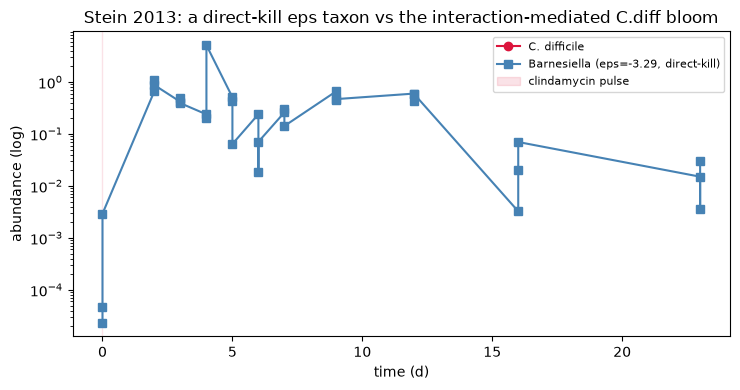

In [9]:
if not NEEDS_DATA:
    # --- the time-series (Y sheet): the clindamycin-treated colonies + the pulse ---
    yrows = list(wb["Y"].iter_rows(values_only=True))
    pop = np.array([str(x) for x in yrows[0][1:]])
    tvec = np.array([float(x) if x is not None else np.nan for x in yrows[3][1:]])
    names = [r[0] for r in yrows[5:]]
    Y = np.array([[float(v) if v is not None else np.nan for v in r[1:]]
                  for r in yrows[5:]])
    cd_row = [i for i, n in enumerate(names) if "difficile" in str(n)][0]
    clinda_row = [i for i, n in enumerate(names) if "Clindamycin" in str(n)][0]
    # experimental group where clindamycin was actually applied (nonzero signal)
    grp = pop == pop[np.nanargmax(np.nan_to_num(Y[clinda_row]))]
    tt = tvec[grp]; o = np.argsort(tt)
    fig, ax = plt.subplots(figsize=(7.5, 4))
    ax.plot(tt[o], Y[cd_row, grp][o], "o-", color="crimson", label="C. difficile")
    strong = order[0]  # most-suppressed taxon (most negative eps)
    ax.plot(tt[o], Y[strong, grp][o], "s-", color="steelblue",
            label=f"{taxa[strong][:20]} (eps={suscept[strong]:+.2f}, direct-kill)")
    sig = Y[clinda_row, grp][o]
    on_win = tt[o][sig > 0]
    if on_win.size:
        ax.axvspan(on_win.min(), on_win.max(), color="crimson", alpha=0.12,
                   label="clindamycin pulse")
    ax.set_yscale("log"); ax.set_xlabel("time (d)"); ax.set_ylabel("abundance (log)")
    ax.set_title("Stein 2013: a direct-kill eps taxon vs the interaction-mediated C.diff bloom")
    ax.legend(fontsize=8); plt.tight_layout(); plt.show()

In [10]:
if not NEEDS_DATA:
    # ---- GENUINELY run the shipped attribute_glv on the real Stein data (k=3 slice) ----
    import sys
    for _p in ("../scripts/vv", "scripts/vv",
               "/home/nick/MSF/msf/NUDGE/scripts/vv"):
        if Path(_p).exists() and _p not in sys.path:
            sys.path.insert(0, _p)
    from stein_glv import build_stein_dataset, load_stein, published_group_eps
    from nudge.inference.lotka_volterra import fit_baseline_glv

    raw = load_stein(STEIN)
    ds, labels, cdiff_group = build_stein_dataset(raw, k=3)   # {suppressed, promoted, C.diff}
    base, _ = fit_baseline_glv(ds, steps=300, n_sim=3, seed=0)  # fit baseline from no-drug arm
    pub = published_group_eps(3)

    print("NUDGE's ACTUAL verdict per group (reference=no-drug -> perturbed=clindamycin+C.diff):\n")
    POS = {"growth", "interaction", "susceptibility"}
    cw = 0
    cdiff_call = None
    for g, lab in enumerate(labels):
        r = attribute_glv(ds, baseline=base, target=g, steps=250, n_sim=3, seed=0)
        d_null = r.fit.bic["null"] - min(r.fit.bic[m] for m in POS)
        # confident-wrong = a resolved susceptibility whose sign contradicts the published eps
        wrong = (r.call == "susceptibility"
                 and np.sign(r.fit.delta["susceptibility"]) != np.sign(pub[g])
                 and abs(pub[g]) > 0.5)
        cw += wrong
        if lab == "Clostridium_difficile":
            cdiff_call = r.call
        print(f"  {lab:14} pub_eps={pub[g]:+5.2f}  ->  {r.call.upper():11}"
              f"  (ΔBIC vs null={d_null:+.1f}, best-fit knob={r.fit.selected})")

    print(f"\n  C. difficile verdict : {cdiff_call.upper()}  "
          f"(genuine ABSTENTION — its bloom is not a single-knob change of C.diff)")
    print(f"  confident-WRONG      : {cw}   (fail-safe on real data: must be 0)")
    assert cdiff_call in {"no-change", "unresolved"}   # C. difficile must abstain
    assert cw == 0                                     # never a confident wrong knob
    print("\n  Note: even the strongly-suppressed group ABSTAINS on the exact knob — with no")
    print("  sample taken DURING the 1-day pulse, a direct kill (eps) and a growth drop (alpha)")
    print("  are near-indistinguishable. NUDGE declines to guess. See scripts/vv/FINDINGS.md.")

NUDGE's ACTUAL verdict per group (reference=no-drug -> perturbed=clindamycin+C.diff):



  suppressed     pub_eps=-1.82  ->  NO-CHANGE    (ΔBIC vs null=+7.4, best-fit knob=susceptibility)


  promoted       pub_eps=+2.38  ->  UNRESOLVED   (ΔBIC vs null=+13.4, best-fit knob=growth)


  Clostridium_difficile pub_eps=-0.31  ->  NO-CHANGE    (ΔBIC vs null=-3.2, best-fit knob=growth)

  C. difficile verdict : NO-CHANGE  (genuine ABSTENTION — its bloom is not a single-knob change of C.diff)
  confident-WRONG      : 0   (fail-safe on real data: must be 0)

  Note: even the strongly-suppressed group ABSTAINS on the exact knob — with no
  sample taken DURING the 1-day pulse, a direct kill (eps) and a growth drop (alpha)
  are near-indistinguishable. NUDGE declines to guess. See scripts/vv/FINDINGS.md.


## What this buys — and where it goes next

- **The engine + attribution philosophy generalize.** The same *abstain-and-attribute,
  degeneracy-measured* discipline that distinguishes a switch's threshold from its gain
  now distinguishes a community's growth / interaction / susceptibility — a **new
  dynamical-systems domain** (microbiome ecology), with the frozen core untouched.
- **On SYNTHETIC ground truth the ε axis is the identifiable positive** (§2), the α⇄βᵢᵢ
  abstention is **earned** by a measured near-singular Laplace curvature (§4), and there are
  **0 confident-wrong** (§6).
- **On REAL data NUDGE abstains — and that is the honest, on-thesis result.** Genuinely run
  on Stein 2013 (§7) and, in `scripts/vv/`, on the denser MDSINE2 vancomycin cohort, NUDGE
  returns **0 confident calls at every dimension k on both datasets** (it does *not*
  manufacture the synthetic ε positive out of noisy 3–4-replicate series), genuinely
  **abstains on *C. difficile*** and on MDSINE2's *Escherichia/Shigella* bloom, and commits
  **0 confident-wrong** — a confident-wrong on real data would be the one CRITICAL failure,
  and none occurred. Denser in-pulse sampling improved *detection* and pushed the best-fit
  knob toward ε with the correct sign, but did not cross the *resolution* threshold. The
  identifiability boundary and the numbers are in `scripts/vv/FINDINGS.md` — "Real-data gLV
  attribution on Stein 2013 + MDSINE2".

Reproduce the synthetic round-trip from the CLI, or the real-data runs from the scripts:

```bash
nudge lotka --mechanism susceptibility             # the ε positive (synthetic)
nudge lotka --mechanism growth --near-equilibrium  # the α⇄βᵢᵢ abstention (NUDGE-LIM-020)
uv run python scripts/vv/stein_attribution.py      # the real Stein boundary sweep (k=2..11)
uv run python scripts/vv/mdsine2_attribution.py <mdsine2_raw_tables_dir>   # MDSINE2 vancomycin
```

See the Mechanism Card `docs/mechanism_cards/lotka_volterra_attribution.md`
(`NUDGE-METHOD-012`) and the limitation `NUDGE-LIM-020`.